## **Model Comparison**

In this notebook, we will:
- Load the evaluation results from each model.
- Compare the models using unsupervised metrics like Silhouette Score.
- Visualize and analyze the embeddings and retrieval results.
- Draw conclusions about the relative performance of each model.

---

## **Table of Contents**
---

1. Import Libraries
2. Load Embeddings and Evaluation Data
3. Compare Embedding Distributions
4. Compute and Compare Unsupervised Metrics
5. Visualize Embeddings Using Dimensionality Reduction
6. Compare Retrieval Results
7. Conclusion

---
### **Step 1: Import Libraries**

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import faiss
import random

---
### **Step 2: Load Embeddings and Evaluation Data**

We'll load the embeddings and any evaluation data for each model.

In [3]:
# List of models
models = ['PLIP', 'UNI', 'DINO', 'CLIP']

# Dictionary to hold embeddings and image files
model_data = {}

for model in models:
    # Load embeddings and image files
    embeddings = np.load(f'embeddings_{model.lower()}.npy')
    image_files = np.load(f'image_files_{model.lower()}.npy')
    
    # Store in the dictionary
    model_data[model] = {
        'embeddings': embeddings,
        'image_files': image_files
    }
    
    print(f'{model}:')
    print(f'  Embeddings shape: {embeddings.shape}')
    print(f'  Number of images: {len(image_files)}\n')

PLIP:
  Embeddings shape: (3360, 512)
  Number of images: 3360

UNI:
  Embeddings shape: (3360, 1024)
  Number of images: 3360

DINO:
  Embeddings shape: (3360, 768)
  Number of images: 3360

CLIP:
  Embeddings shape: (3360, 512)
  Number of images: 3360



---
### **Step 3: Compare Embedding Distributions**

We can compare the distributions of the embeddings from each model to understand their characteristics.

**Compute the Norms of the Embeddings**

In [4]:
for model in models:
    embeddings = model_data[model]['embeddings']
    norms = np.linalg.norm(embeddings, axis=1)
    model_data[model]['norms'] = norms

**Plot the Distribution of Norms**

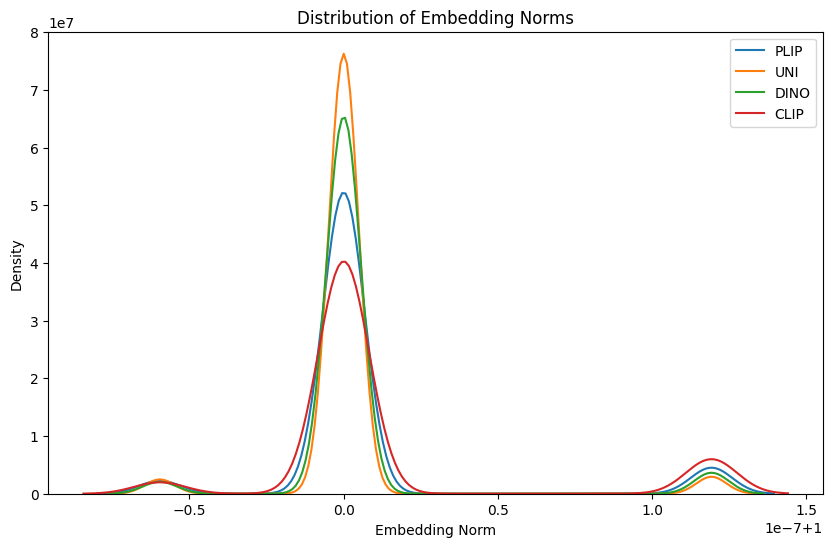

In [5]:
plt.figure(figsize=(10, 6))
for model in models:
    sns.kdeplot(model_data[model]['norms'], label=model)
plt.xlabel('Embedding Norm')
plt.ylabel('Density')
plt.title('Distribution of Embedding Norms')
plt.legend()
plt.show()

---
### **Step 4: Compute and Compare Unsupervised Metrics**

We'll compute the Silhouette Score for each model to evaluate the cohesiveness of the clusters formed by the embeddings.

**Perform K-Means Clustering and Compute Silhouette Score**

In [6]:
# Choose a consistent number of clusters for comparison
num_clusters = 10  # Adjust based on your dataset

# Store the Silhouette Scores
silhouette_scores = {}

for model in models:
    embeddings = model_data[model]['embeddings']
    
    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)
    
    # Compute Silhouette Score
    sil_score = silhouette_score(embeddings, cluster_labels)
    silhouette_scores[model] = sil_score
    
    # Store cluster labels
    model_data[model]['cluster_labels'] = cluster_labels
    
    print(f'{model} Silhouette Score: {sil_score:.4f}')

PLIP Silhouette Score: 0.0312
UNI Silhouette Score: 0.0235
DINO Silhouette Score: 0.0121
CLIP Silhouette Score: 0.0305


**Perform K-Means Clustering and Compute Silhouette Score**

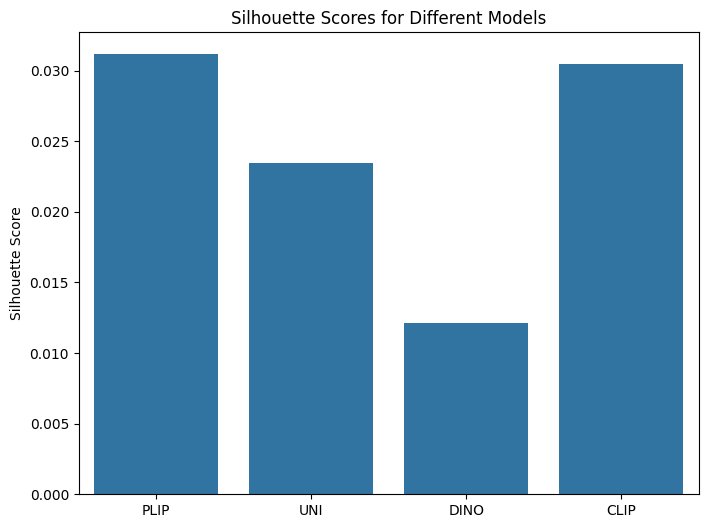

In [7]:
# Create a bar plot of Silhouette Scores
plt.figure(figsize=(8, 6))
scores = [silhouette_scores[model] for model in models]
sns.barplot(x=models, y=scores)
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different Models')
plt.show()

---
### **Step 5: Visualize Embeddings Using Dimensionality Reduction**

We'll use t-SNE to reduce the embeddings to 2D for visualization.

**Compute t-SNE for Each Model**

In [7]:
for model in models:
    embeddings = model_data[model]['embeddings']
    
    # Reduce dimensions to 2D
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    embeddings_2d = tsne.fit_transform(embeddings)
    model_data[model]['embeddings_2d'] = embeddings_2d

/Users/mohammedkhodorfirasal-tal/Documents/Professional/Work/Fellowship - Novartis/Data/venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/Users/mohammedkhodorfirasal-tal/Documents/Professional/Work/Fellowship - Novartis/Data/venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/Users/mohammedkhodorfirasal-tal/Documents/Professional/Work/Fellowship - Novartis/Data/venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/Users/mohammedkhodorfirasal-tal/Documents/Professional/Work/Fellowship - Novartis/Data/venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' 

**Plot t-SNE Visualizations**

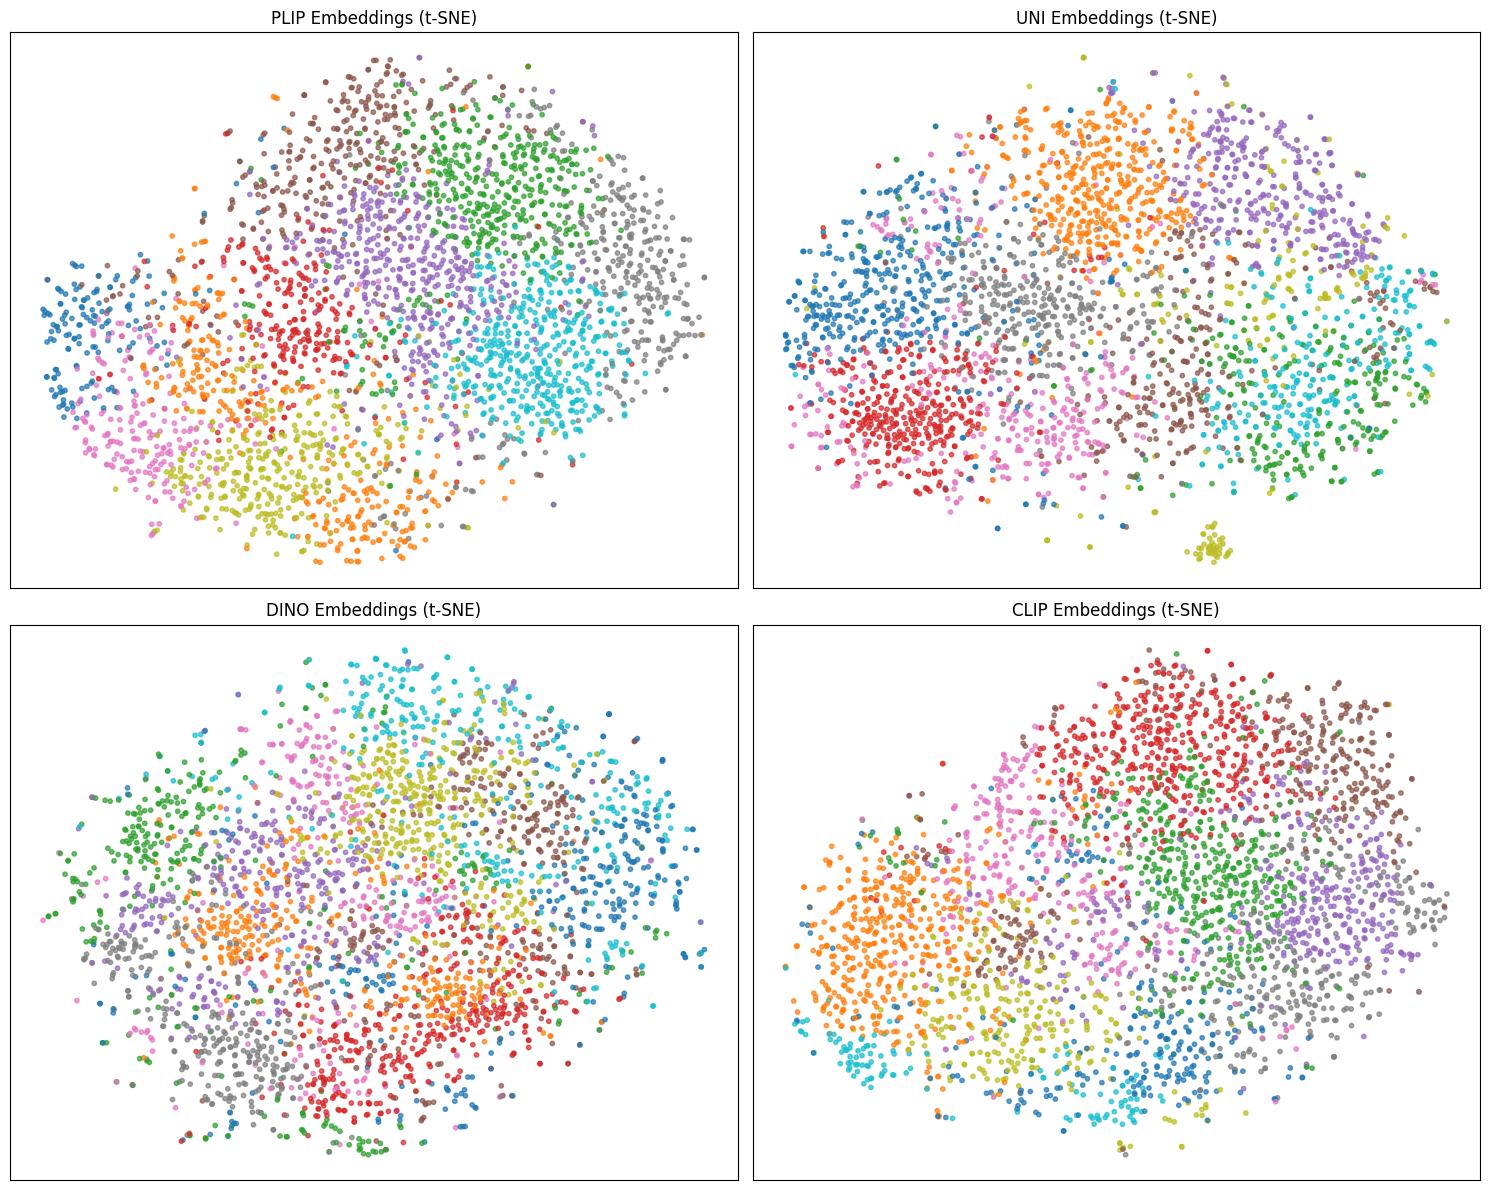

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, model in enumerate(models):
    embeddings_2d = model_data[model]['embeddings_2d']
    cluster_labels = model_data[model]['cluster_labels']
    
    ax = axes[idx]
    scatter = ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cluster_labels, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(f'{model} Embeddings (t-SNE)')
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.tight_layout()
plt.show()

---
### **Step 6: Compare Retrieval Results**

We'll select a few random query images and compare the retrieval results across different models.

**Function to Display Retrieval Results Side by Side**

In [8]:
def display_retrievals_side_by_side(query_image_path, retrieved_image_paths_dict, titles=None):
    num_models = len(retrieved_image_paths_dict)
    num_retrieved = len(next(iter(retrieved_image_paths_dict.values())))
    fig, axes = plt.subplots(num_models + 1, num_retrieved, figsize=(3 * num_retrieved, 3 * (num_models + 1)))
    
    # Display the query image in the first row
    query_img = Image.open(query_image_path)
    for ax in axes[0]:
        ax.imshow(query_img)
        ax.axis('off')
    axes[0, 0].set_ylabel('Query', rotation=0, labelpad=40, fontsize=12)
    
    # Display retrieved images for each model
    for idx, model in enumerate(models):
        retrieved_paths = retrieved_image_paths_dict[model]
        for jdx, img_path in enumerate(retrieved_paths):
            img = Image.open(img_path)
            axes[idx + 1, jdx].imshow(img)
            axes[idx + 1, jdx].axis('off')
        axes[idx + 1, 0].set_ylabel(model, rotation=0, labelpad=40, fontsize=12)
    
    plt.tight_layout()
    plt.show()

**Perform Retrieval and Display Results**

Retrieval Results for Query Image: 8a662f40-e8b5-47d3-9ce5-95c1823e3789.jpg


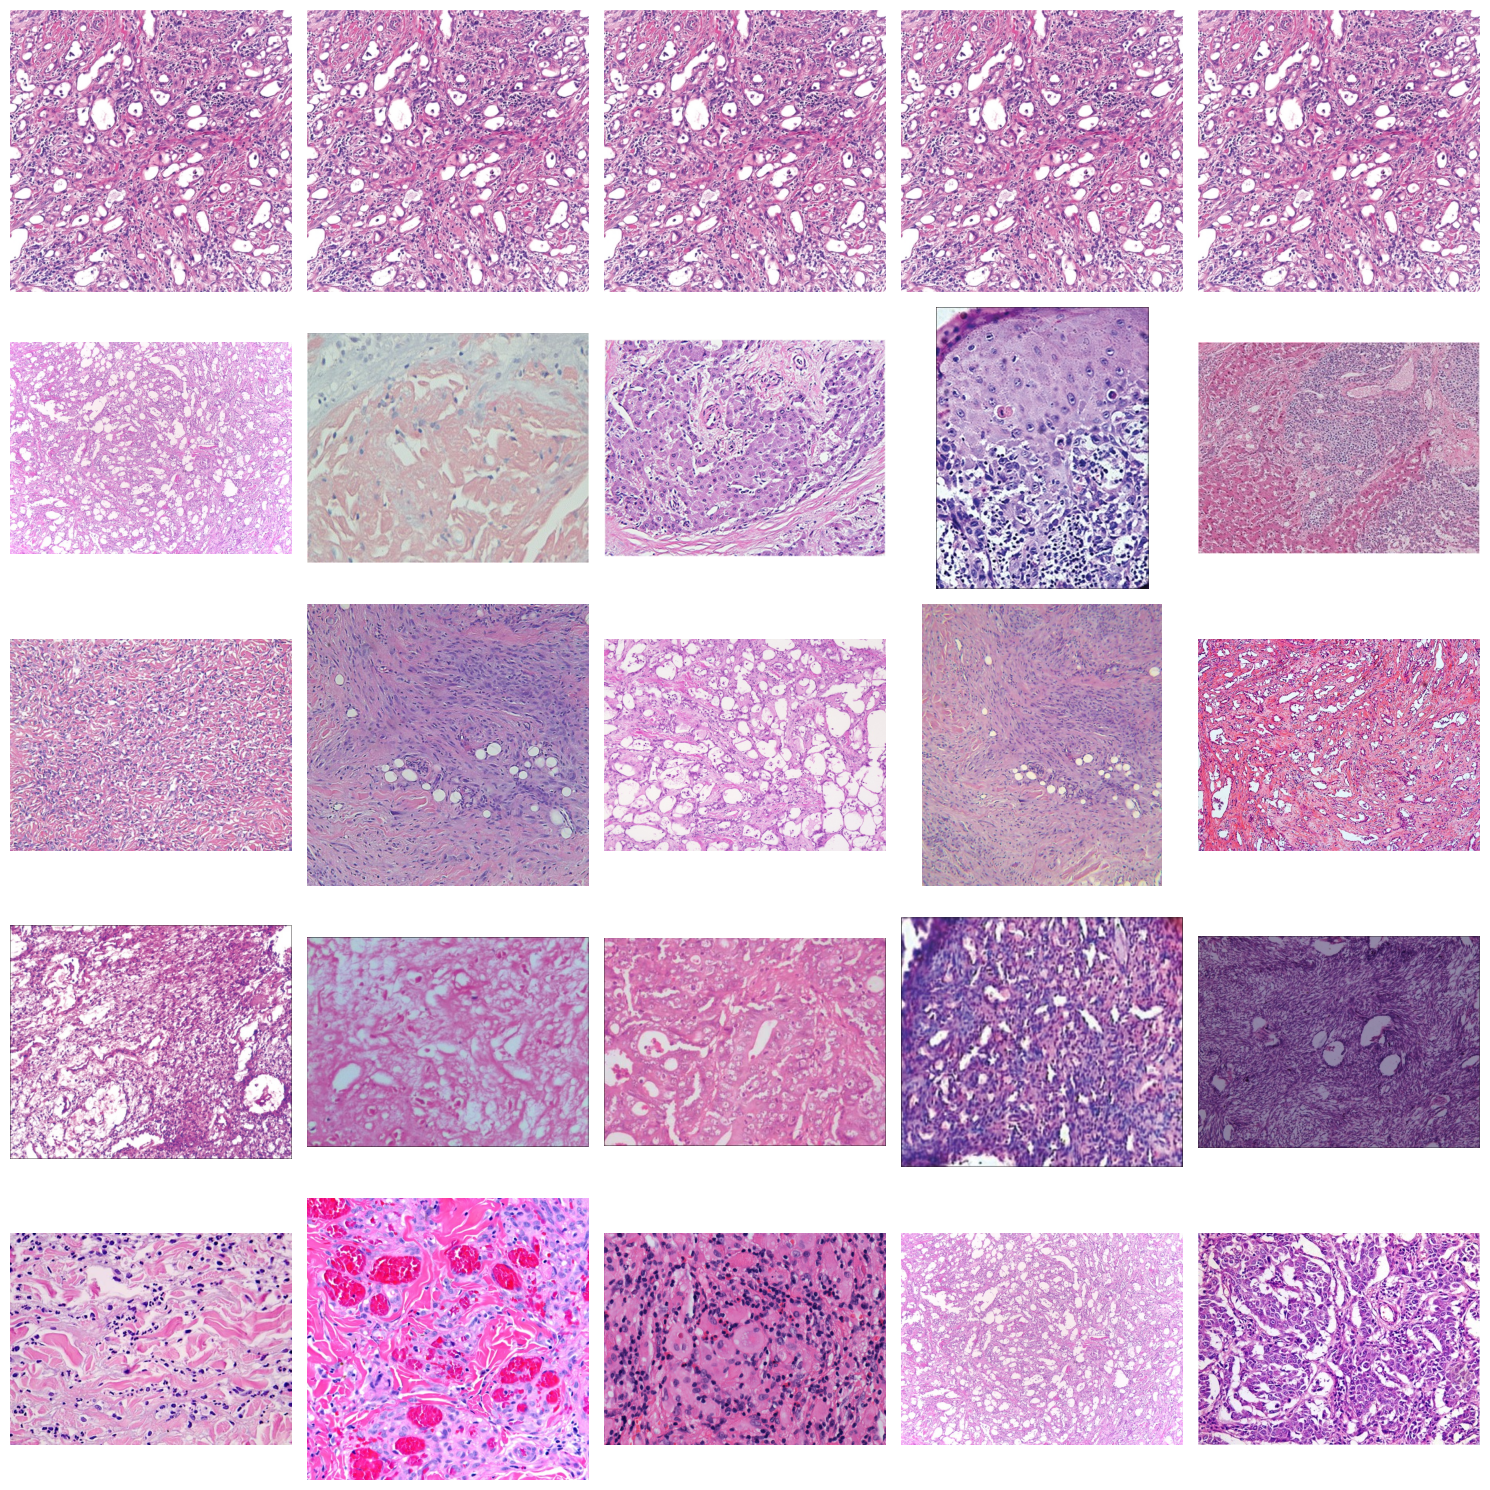

In [16]:
'''
# Number of queries to visualize
num_queries = 3  # Adjust as needed

# Number of retrieved images to display (excluding the query image)
k = 5

# Directory containing original images
original_images_dir = './combined_dataset/'  # Update this path accordingly

# Randomly select query indices
random.seed(42)  # For reproducibility
query_indices = random.sample(range(len(image_files)), num_queries)

for idx in query_indices:
    query_image_file = image_files[idx]
    query_image_path = os.path.join(original_images_dir, query_image_file)
    
    # Dictionary to hold retrieved image paths for each model
    retrieved_image_paths_dict = {}
    
    for model in models:
        embeddings = model_data[model]['embeddings']
        index = faiss.IndexFlatL2(embeddings.shape[1])
        index.add(embeddings)
        
        # Perform search for the query embedding
        query_embedding = embeddings[idx].reshape(1, -1)
        distances, indices = index.search(query_embedding, k + 1)  # +1 to include the query image itself
        
        # Get retrieved image files
        retrieved_indices = indices[0][1:]  # Exclude the query image itself
        retrieved_image_files = model_data[model]['image_files'][retrieved_indices]
        retrieved_image_paths = [os.path.join(original_images_dir, img_file) for img_file in retrieved_image_files]
        
        retrieved_image_paths_dict[model] = retrieved_image_paths
    
    # Display retrieval results
    print(f'Retrieval Results for Query Image: {query_image_file}')
    display_retrievals_side_by_side(query_image_path, retrieved_image_paths_dict)

'''

# Number of queries to visualize
num_queries = 1  # Since we only have one specific query to run

# Number of retrieved images to display (excluding the query image)
k = 5

# Directory containing original images
original_images_dir = './combined_dataset/'  # Update this path accordingly

# Specific query identifier
query_identifier = "8a662f40-e8b5-47d3-9ce5-95c1823e3789.jpg"

# Find the integer index of the query identifier in image_files
query_index = image_files.tolist().index(query_identifier)  # Locate the index of the query

# Retrieve and display results for this single query
query_image_file = image_files[query_index]
query_image_path = os.path.join(original_images_dir, query_image_file)

# Dictionary to hold retrieved image paths for each model
retrieved_image_paths_dict = {}

for model in models:
    embeddings = model_data[model]['embeddings']
    index = faiss.IndexFlatL2(embeddings.shape[1])
    index.add(embeddings)
    
    # Perform search for the query embedding
    query_embedding = embeddings[query_index].reshape(1, -1)
    distances, indices = index.search(query_embedding, k + 1)  # +1 to include the query image itself
    
    # Get retrieved image files
    retrieved_indices = indices[0][1:]  # Exclude the query image itself
    retrieved_image_files = [image_files[i] for i in retrieved_indices]
    retrieved_image_paths = [os.path.join(original_images_dir, img_file) for img_file in retrieved_image_files]
    
    retrieved_image_paths_dict[model] = retrieved_image_paths

# Display retrieval results
print(f'Retrieval Results for Query Image: {query_image_file}')
display_retrievals_side_by_side(query_image_path, retrieved_image_paths_dict)


---
### **Step 7: Conclusion**



**[PLACEHOLDER]**

### **Additional Analysis**

### **1. Embedding Space Properties**

**Distribution of Pairwise Distances:**

In [ ]:
for model in models:
    embeddings = model_data[model]['embeddings']
    # Compute pairwise distances
    distances = np.sqrt(((embeddings[:, np.newaxis, :] - embeddings[np.newaxis, :, :]) ** 2).sum(-1))
    # Flatten the upper triangle of the distance matrix
    tril_indices = np.tril_indices_from(distances, k=-1)
    pairwise_distances = distances[tril_indices]
    model_data[model]['pairwise_distances'] = pairwise_distances

**Plot Distribution of Pairwise Distances:**

In [ ]:
plt.figure(figsize=(10, 6))
for model in models:
    sns.kdeplot(model_data[model]['pairwise_distances'], label=model)
plt.xlabel('Pairwise Distance')
plt.ylabel('Density')
plt.title('Distribution of Pairwise Distances')
plt.legend()
plt.show()

### **2. Cluster Analysis**

**Cluster Sizes:**

In [ ]:
for model in models:
    cluster_labels = model_data[model]['cluster_labels']
    unique, counts = np.unique(cluster_labels, return_counts=True)
    cluster_sizes = dict(zip(unique, counts))
    model_data[model]['cluster_sizes'] = cluster_sizes
    print(f'{model} Cluster Sizes:')
    print(cluster_sizes)

**Plot Cluster Sizes:**

In [ ]:
for model in models:
    cluster_sizes = model_data[model]['cluster_sizes']
    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(cluster_sizes.keys()), y=list(cluster_sizes.values()))
    plt.xlabel('Cluster Label')
    plt.ylabel('Number of Images')
    plt.title(f'{model} Cluster Sizes')
    plt.show()

### **3. Aggregate the Results**

In [ ]:
summary_df = pd.DataFrame({
    'Model': models,
    'Silhouette Score': [silhouette_scores[model] for model in models]
})
summary_df